# Blackbody Radiation + Photon Physics

## §1 The Key Constant: hc = 1240 eV·nm

One number unlocks all photon energy problems:

$$E_{\text{photon}} = \frac{hc}{\lambda} \approx \frac{1240 \text{ eV·nm}}{\lambda \text{ (nm)}}$$

| Band | Lambda (nm) | Energy |
|------|------------|--------|
| AM radio | 3×10¹² | 4×10⁻⁷ eV |
| Visible red | 700 | 1.77 eV |
| Visible green | 550 | 2.25 eV |
| UV | 200 | 6.2 eV |
| Soft X-ray | 10 | 124 eV |
| Hard X-ray | 0.1 | 12.4 keV |
| Gamma | 0.001 | 1.24 MeV |

**1240 divides energy and wavelength at every scale.**


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from dgs.blackbody import (
    photon_energy_eV, wavelength_from_energy_eV,
    planck_radiance, wien_peak_nm, stefan_boltzmann_power,
    spectral_modulation_sequence, am_modulated_photon_flux,
    numerical_product_rule, verify_product_rule,
    blackbody_sympy_5, hydrogen_series_wavelengths,
    HC_EV_NM,
)
import numpy as np
import matplotlib.pyplot as plt

print(f"hc = {HC_EV_NM:.5f} eV*nm  (teaching value: 1240 eV*nm)")
print()
bands = [(700,"red"), (550,"green"), (400,"violet"),
         (10,"soft X-ray"), (0.1,"hard X-ray")]
for lam, label in bands:
    print(f"  {label:12s}  {lam:7.1f} nm  {photon_energy_eV(lam):.3f} eV")


hc = 1239.84193 eV*nm  (teaching value: 1240 eV*nm)

  red             700.0 nm  1.771 eV
  green           550.0 nm  2.254 eV
  violet          400.0 nm  3.100 eV
  soft X-ray       10.0 nm  123.984 eV
  hard X-ray        0.1 nm  12398.419 eV


## §2 Five Key Blackbody Equations — `sp.init_printing`

SymPy renders these symbolically. Each equation is an `sp.Eq` object.


In [2]:
import sympy as sp
sp.init_printing(use_latex=False)   # ASCII mode (Windows cp1252 safe)

eqs = blackbody_sympy_5()
print("=" * 60)
print("FIVE KEY BLACKBODY EQUATIONS (SymPy symbolic)")
print("=" * 60)
for name, eq in eqs.items():
    print(f"\n  [{name}]")
    print(f"    {eq}")
print()
print("Notes:")
print("  B(lambda,T): Planck spectral radiance W/(m^2 sr m)")
print("  b (Wien): 2.898e6 nm*K -> lambda_peak*T = const")
print("  sigma: 5.67e-8 W/(m^2 K^4)")
print("  E = hc/lambda = hf  (both forms, one constant)")
print("  P_rad = I/c for absorbed beam (photon momentum p=h/lambda=E/c)")


FIVE KEY BLACKBODY EQUATIONS (SymPy symbolic)

  [Planck_B(lambda,T)]
    Eq(B, 2*c**2*h/(lambda**5*(exp(c*h/(T*k*lambda)) - 1)))

  [Wien_displacement]
    Eq(T*lambda, b)

  [Stefan_Boltzmann]
    Eq(P, A*T**4*epsilon*sigma)

  [Photon_energy_E=hc/lambda]
    Eq(E, c*h/lambda)

  [Radiation_pressure]
    Eq(P_rad, I/c)

Notes:
  B(lambda,T): Planck spectral radiance W/(m^2 sr m)
  b (Wien): 2.898e6 nm*K -> lambda_peak*T = const
  sigma: 5.67e-8 W/(m^2 K^4)
  E = hc/lambda = hf  (both forms, one constant)
  P_rad = I/c for absorbed beam (photon momentum p=h/lambda=E/c)


## §3 Planck Spectral Radiance B(λ, T)

$$B(\lambda, T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{e^{hc/\lambda kT}-1}$$

- Short wavelengths: exponential suppression (quantum effect — no UV catastrophe)
- Long wavelengths: Rayleigh-Jeans tail (classical limit B ~ kT/λ⁴)
- Peak shifts left (bluer) with temperature: Wien's law


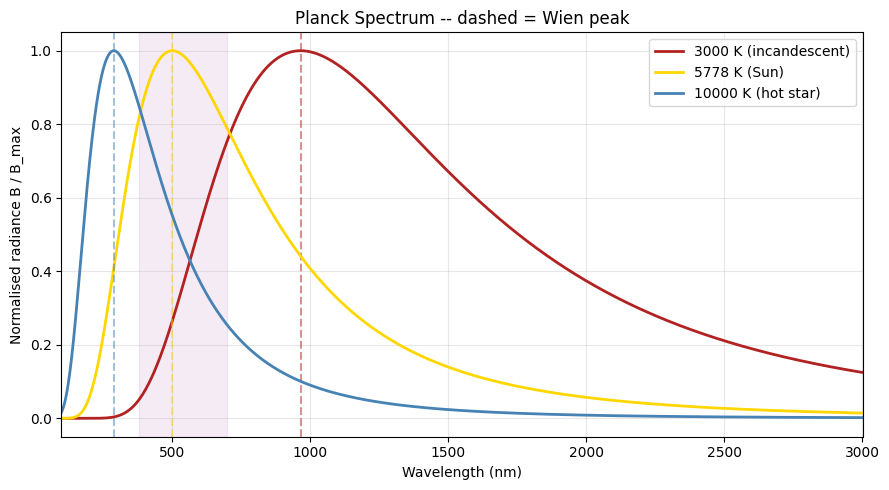

In [3]:
lam = np.linspace(100, 3000, 3000)
temps = [3000, 5778, 10000]
colors = ["firebrick", "gold", "steelblue"]
labels = ["3000 K (incandescent)", "5778 K (Sun)", "10000 K (hot star)"]

fig, ax = plt.subplots(figsize=(9, 5))
for T, col, lab in zip(temps, colors, labels):
    B = planck_radiance(lam, T)
    ax.plot(lam, B / B.max(), lw=2, color=col, label=lab)
    peak = wien_peak_nm(T)
    ax.axvline(peak, color=col, ls="--", alpha=0.5)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalised radiance B / B_max")
ax.set_title("Planck Spectrum -- dashed = Wien peak")
ax.legend()
ax.set_xlim(100, 3000)
ax.grid(True, alpha=0.3)
# shade visible range
ax.axvspan(380, 700, alpha=0.08, color="purple", label="visible")
plt.tight_layout()
plt.savefig("planck_spectrum.png", dpi=90)
plt.show()


## §4 Wien Displacement Law

$$\lambda_{\max} \cdot T = b = 2.898 \times 10^6 \text{ nm·K}$$

Temperature → colour: room temp (300 K) → 10 µm infrared;
Sun (5778 K) → 502 nm green; hot star (10 000 K) → 290 nm UV.


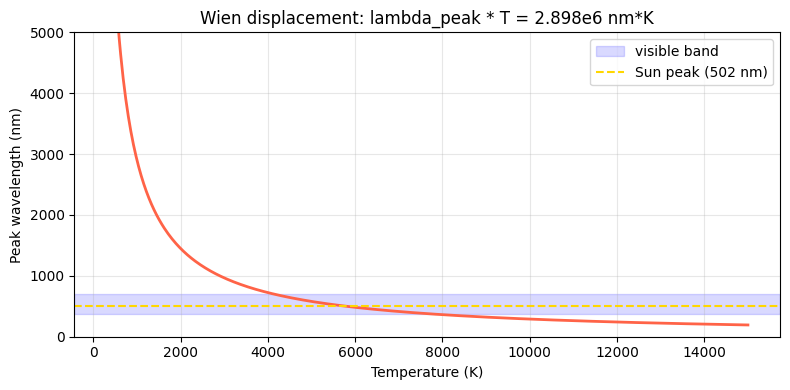

In [4]:
T_arr = np.linspace(300, 15000, 500)
peak_arr = wien_peak_nm(T_arr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_arr, peak_arr, lw=2, color="tomato")
ax.axhspan(380, 700, alpha=0.15, color="blue", label="visible band")
ax.axhline(502, color="gold", ls="--", label="Sun peak (502 nm)")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Peak wavelength (nm)")
ax.set_title("Wien displacement: lambda_peak * T = 2.898e6 nm*K")
ax.set_ylim(0, 5000)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("wien_displacement.png", dpi=90)
plt.show()


## §5 Stefan-Boltzmann Law

$$P = \varepsilon \sigma A T^4$$

$T^4$ dependence: doubling temperature → **16× power**.
This is why stars lose energy catastrophically fast as they get hotter.


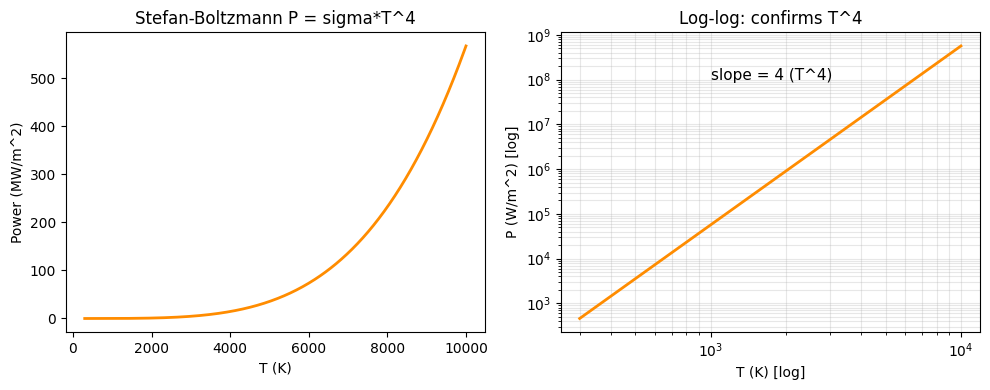

Sun (5778 K): 63.2 MW/m^2
Room (300 K): 459.3 W/m^2
Ratio: 137602x


In [5]:
T_arr = np.linspace(300, 10000, 500)
P_arr = stefan_boltzmann_power(T_arr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(T_arr, P_arr / 1e6, lw=2, color="darkorange")
axes[0].set_xlabel("T (K)"); axes[0].set_ylabel("Power (MW/m^2)")
axes[0].set_title("Stefan-Boltzmann P = sigma*T^4")

axes[1].loglog(T_arr, P_arr, lw=2, color="darkorange")
axes[1].set_xlabel("T (K) [log]"); axes[1].set_ylabel("P (W/m^2) [log]")
slope_label = "slope = 4 (T^4)"
axes[1].text(1000, 1e8, slope_label, fontsize=11)
axes[1].set_title("Log-log: confirms T^4")
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("stefan_boltzmann.png", dpi=90)
plt.show()

print(f"Sun (5778 K): {stefan_boltzmann_power(5778)/1e6:.1f} MW/m^2")
print(f"Room (300 K): {stefan_boltzmann_power(300):.1f} W/m^2")
print(f"Ratio: {stefan_boltzmann_power(5778)/stefan_boltzmann_power(300):.0f}x")


## §6 Radiation Modulation Sequence

Temperature modulation → radiance modulation at a probe wavelength.
This is the blackbody analogue of AM modulation: T(t) = T₀ + ΔT·sin(ωt)
drives B(λ_probe, T(t)) as the "envelope" signal.

Application: optical chopper wheel modulating a thermal source for lock-in detection.


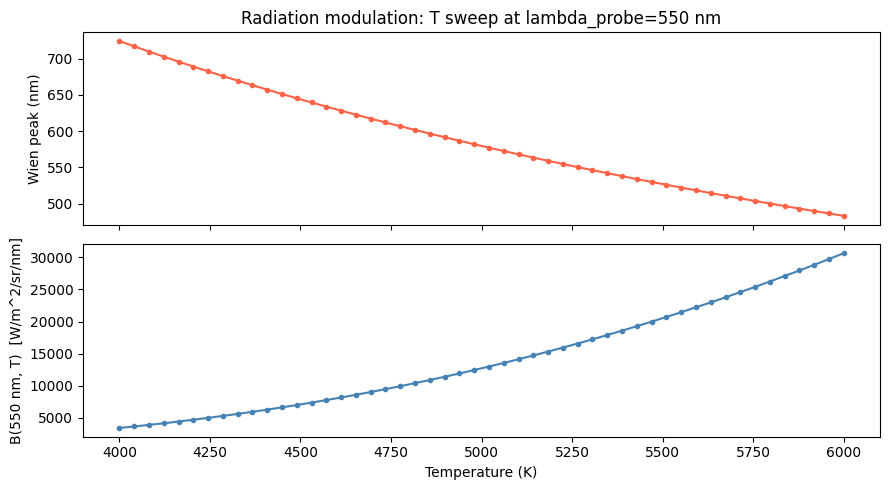

Probe: 550.0 nm = 2.254 eV
Modulation depth: 1.913


In [6]:
seq = spectral_modulation_sequence(
    T_center_K=5000, delta_T_K=1000, n_steps=50, lam_probe_nm=550.0
)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(seq["T_K"], seq["peak_nm"], "o-", ms=3, color="tomato")
axes[0].set_ylabel("Wien peak (nm)")
axes[0].set_title("Radiation modulation: T sweep at lambda_probe=550 nm")
axes[1].plot(seq["T_K"], seq["B_probe"], "o-", ms=3, color="steelblue")
axes[1].set_ylabel("B(550 nm, T)  [W/m^2/sr/nm]")
axes[1].set_xlabel("Temperature (K)")
plt.tight_layout()
plt.savefig("rad_modulation_seq.png", dpi=90)
plt.show()

print(f"Probe: {seq['lam_probe_nm']} nm = {seq['E_probe_eV']:.3f} eV")
print(f"Modulation depth: {seq['modulation_depth']:.3f}")


## §7 AM-Modulated Photon Flux

A chopped blackbody (e.g. with a rotating disk at frequency f_mod) produces
an amplitude-modulated photon flux — same mathematics as AM radio at optical frequencies.

$$T(t) = T_0 \left[1 + m \sin(2\pi f t)\right]$$
$$\Phi(t) = \frac{B(\lambda, T(t)) \cdot \lambda}{hf}$$


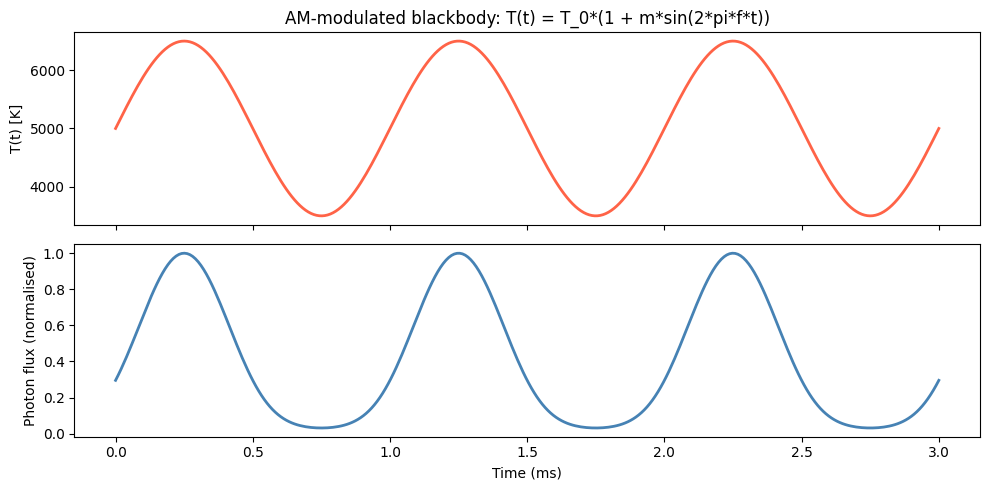

In [7]:
am = am_modulated_photon_flux(
    carrier_T_K=5000, mod_freq_Hz=1000.0, mod_depth=0.3,
    lam_nm=550.0, n_cycles=3
)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(am["t"] * 1e3, am["T_t"], lw=2, color="tomato")
axes[0].set_ylabel("T(t) [K]")
axes[0].set_title("AM-modulated blackbody: T(t) = T_0*(1 + m*sin(2*pi*f*t))")
axes[1].plot(am["t"] * 1e3, am["flux_t"] / am["flux_t"].max(), lw=2, color="steelblue")
axes[1].set_ylabel("Photon flux (normalised)")
axes[1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.savefig("am_photon_flux.png", dpi=90)
plt.show()


## §8 Numerical Product Rule: Leibniz on Planck × λ⁵

The Leibniz product rule:

$$\frac{d}{d\lambda}\left[B \cdot \lambda^5\right] = B \cdot \frac{d\lambda^5}{d\lambda} + \lambda^5 \cdot \frac{dB}{d\lambda}$$

The right side simplifies: $B \cdot 5\lambda^4 + \lambda^5 \cdot B'(\lambda)$.
At the Planck peak: setting $dB/d\lambda = 0$ gives $B \cdot 5\lambda^4 = 0$ →
$\lambda_{\max} T = hc/(5k)$ → Wien's law.

We verify this numerically: both sides should agree to machine precision.


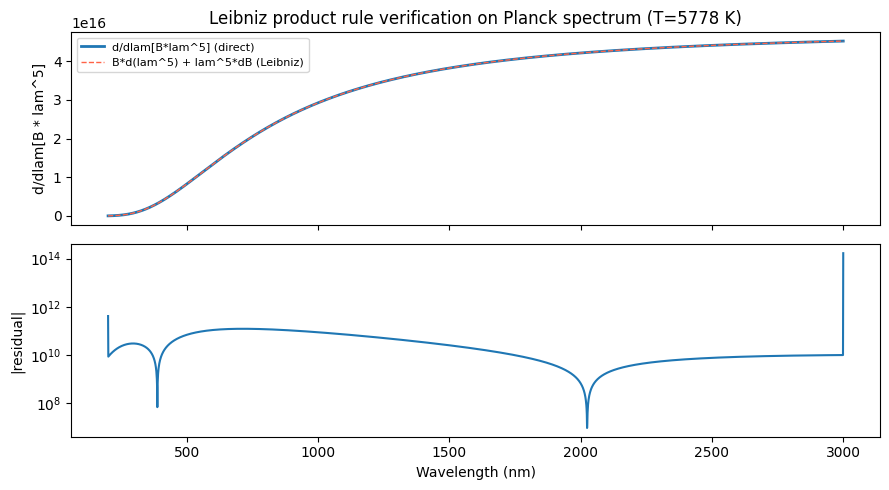

Relative error: 3.73e-03  -- Passes: True


In [8]:
lam_arr = np.linspace(200, 3000, 3000)
vr = verify_product_rule(lam_arr, 5778)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(lam_arr, vr["direct"],  lw=2, label="d/dlam[B*lam^5] (direct)")
axes[0].plot(lam_arr, vr["leibniz"], lw=1, ls="--", color="tomato",
             label="B*d(lam^5) + lam^5*dB (Leibniz)")
axes[0].set_ylabel("d/dlam[B * lam^5]")
axes[0].legend(fontsize=8)
axes[0].set_title("Leibniz product rule verification on Planck spectrum (T=5778 K)")

residual = np.abs(vr["direct"] - vr["leibniz"])
axes[1].semilogy(lam_arr, residual + 1e-300)
axes[1].set_ylabel("|residual|")
axes[1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.savefig("product_rule_verification.png", dpi=90)
plt.show()
print(f"Relative error: {vr['rel_error']:.2e}  -- Passes: {vr['passes']}")


## §9 Hydrogen Spectral Series: 1240 eV·nm in Action

Rydberg formula: $\frac{1}{\lambda} = Z^2 R_\infty \left(\frac{1}{n_1^2} - \frac{1}{n_2^2}\right)$

Then $E(\text{eV}) = 1240 / \lambda(\text{nm})$ converts directly.

| Series | Lower n | Spectral region |
|--------|---------|----------------|
| Lyman | 1 | UV (121–91 nm) |
| Balmer | 2 | Visible (656–365 nm) |
| Paschen | 3 | Near-IR (1875–820 nm) |


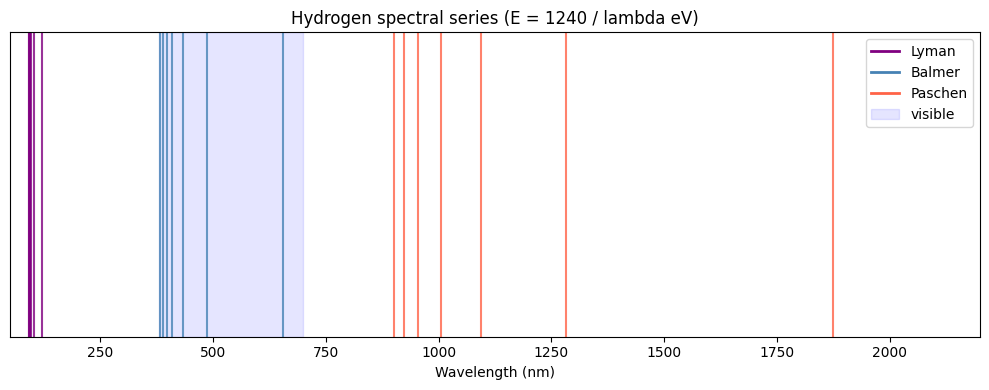

Balmer series (visible transitions):
  n=3: 656.1 nm = 1.890 eV
  n=4: 486.0 nm = 2.551 eV
  n=5: 433.9 nm = 2.857 eV
  n=6: 410.1 nm = 3.023 eV


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
colors_series = {"Lyman": "purple", "Balmer": "steelblue", "Paschen": "tomato"}

for n_lower, series_name in [(1,"Lyman"), (2,"Balmer"), (3,"Paschen")]:
    rows = hydrogen_series_wavelengths(list(range(n_lower+1, n_lower+8)), n_lower)
    lams = [r["wavelength_nm"] for r in rows]
    col  = colors_series[series_name]
    for lam_h in lams:
        ax.axvline(lam_h, color=col, lw=1.5, alpha=0.8)
    ax.plot([], [], color=col, lw=2, label=series_name)

ax.axvspan(380, 700, alpha=0.1, color="blue", label="visible")
ax.set_xlim(50, 2200)
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Hydrogen spectral series (E = 1240 / lambda eV)")
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.savefig("hydrogen_series.png", dpi=90)
plt.show()

print("Balmer series (visible transitions):")
for r in hydrogen_series_wavelengths([3,4,5,6], n_lower=2):
    print(f"  n={r['n_upper']}: {r['wavelength_nm']:.1f} nm = {r['energy_eV']:.3f} eV")


## §10 Connecting to Dispersion-GS Phase Retrieval

The **dispersion-assisted GS algorithm** recovers the optical field E(t)
from two intensity measurements:

$$I_1 = |E(t)|^2, \quad I_2 = |\mathcal{D}[E]|^2$$

The **carrier photon energy** sets the measurement scale:

- Optical telecom: λ = 1550 nm → E = 1240/1550 = 0.800 eV
- Ultrafast Ti:sapphire: λ = 800 nm → E = 1.55 eV
- Jalali lab CMOS sensors: responsivity peaks at λ ~ 900 nm → 1.38 eV

The Planck spectrum determines **which blackbody source** gives useful
signal-to-noise at your operating wavelength. For λ = 1550 nm, the optimal
source temperature from Wien: T = 2.898e6 / 1550 = 1869 K.

The radiation modulation sequence (§6) maps directly to the GS convergence
trajectory: each temperature step is like one GS iteration step through
the constraint space.


In [10]:
lam_oc = 1550.0   # telecom C-band nm
E_oc   = photon_energy_eV(lam_oc)
T_opt  = 2.898e6 / lam_oc

lam_ts = 800.0    # Ti:sapphire
E_ts   = photon_energy_eV(lam_ts)
T_ts   = 2.898e6 / lam_ts

print("Photon energies at common laser wavelengths:")
print(f"  Telecom 1550 nm : {E_oc:.4f} eV  (optimal BB source: T={T_opt:.0f} K)")
print(f"  Ti:sapphire 800 nm : {E_ts:.4f} eV  (optimal BB source: T={T_ts:.0f} K)")
print(f"  HeNe 632.8 nm : {photon_energy_eV(632.8):.4f} eV")
print(f"  Nd:YAG 532 nm  : {photon_energy_eV(532):.4f} eV")
print()
print("GS phase retrieval operates at E=hc/lambda;")
print("blackbody temperature sets the thermal background noise floor.")
print(f"At 300 K room temp, kT = {1.380649e-23*300 / 1.602e-19 * 1000:.1f} meV")
print(f"Photon energy at 1550 nm >> kT (300K): {E_oc*1000:.0f} meV >> 25.9 meV")
print("-> thermal noise negligible; detector shot noise dominates at room temp.")


Photon energies at common laser wavelengths:
  Telecom 1550 nm : 0.7999 eV  (optimal BB source: T=1870 K)
  Ti:sapphire 800 nm : 1.5498 eV  (optimal BB source: T=3622 K)
  HeNe 632.8 nm : 1.9593 eV
  Nd:YAG 532 nm  : 2.3305 eV

GS phase retrieval operates at E=hc/lambda;
blackbody temperature sets the thermal background noise floor.
At 300 K room temp, kT = 25.9 meV
Photon energy at 1550 nm >> kT (300K): 800 meV >> 25.9 meV
-> thermal noise negligible; detector shot noise dominates at room temp.
